In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from scipy import stats

from ipynb.fs.defs.functions import top_bottom_n, top_bottom_n_split, find_outliers_iqr

In [15]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ', 'ROR', 'erz. Hilfen absolut', 'erz. Hilfen pro 10000',
       '35a Hilfen absolut', '35a Hilfen pro 10000', 'Überörtlicher Träger',
       'Bevölkerung 6 bis 20', 'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote',
       'Kinderarztdichte', 'KJP-Dichte'],
      dtype='object')

In [16]:
df["35a Hilfen pro 10000"].describe()

count     52.000000
mean     182.865385
std       67.057198
min       69.000000
25%      140.000000
50%      170.000000
75%      228.500000
max      326.000000
Name: 35a Hilfen pro 10000, dtype: float64

In [17]:
#top_bottom_n(df, "35a Hilfen pro 10000", n=5)
top_bottom_n_split(df, "35a Hilfen pro 10000", n=3)

=== Kreise ===

Top 3 (hÃ¶chste Werte):
                          Name  35a Hilfen pro 10000
25           Ennepe-Ruhr-Kreis                   306
24                       Düren                   301
44  Rheinisch-Bergischer Kreis                   265

Bottom 3 (niedrigste Werte):
         Name  35a Hilfen pro 10000
47  Steinfurt                    74
50  Warendorf                    93
29    Herford                    94


=== Kreisfreie StÃ¤dte ===

Top 3 (hÃ¶chste Werte):
                   Name  35a Hilfen pro 10000
12                 Köln                   326
15  Mülheim an der Ruhr                   286
13           Leverkusen                   284

Bottom 3 (niedrigste Werte):
             Name  35a Hilfen pro 10000
6      Düsseldorf                    69
7   Gelsenkirchen                    77
17     Oberhausen                    99


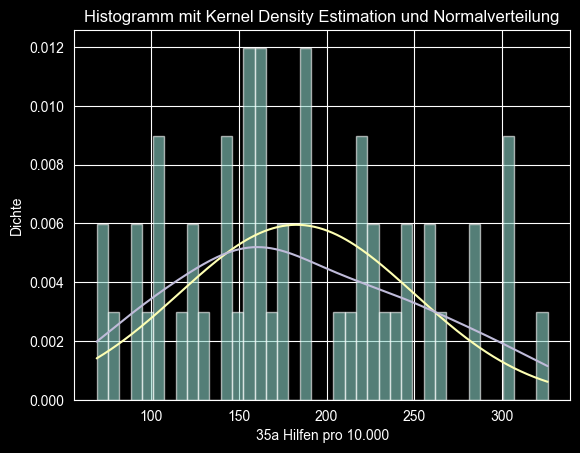

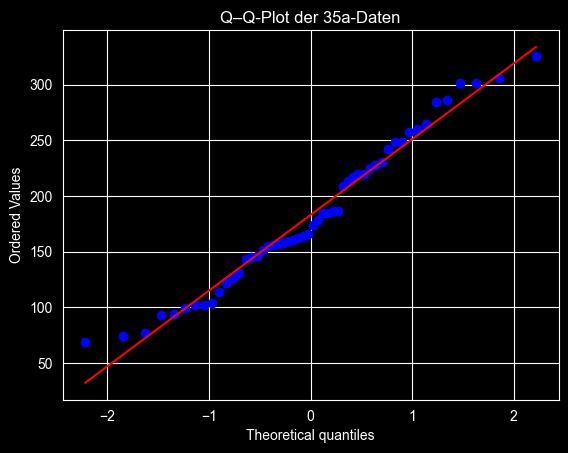

In [26]:
x = df["35a Hilfen pro 10000"].to_numpy()

plt.figure()
plt.hist(x, bins=40, density=True, alpha=0.6)

xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, stats.norm.pdf(xx, mu, sd))

#bandwith variiert
kde = stats.gaussian_kde(x, bw_method=0.5)
plt.plot(xx, kde(xx))


plt.xlabel("35a Hilfen pro 10.000")
plt.ylabel("Dichte")
plt.title("Histogramm mit Kernel Density Estimation und Normalverteilung")
plt.show()


plt.figure()
stats.probplot(x, dist="norm", plot=plt)
plt.title("Q–Q-Plot der 35a-Daten")
plt.show()

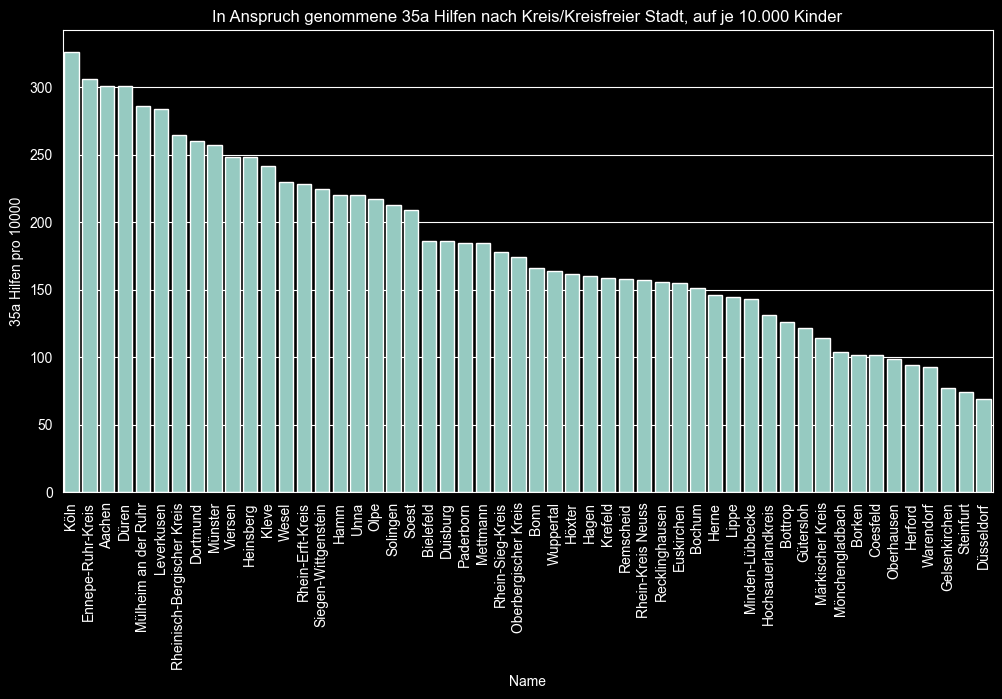

In [6]:
plt.figure(figsize=(12,6))
sns.barplot(data=df.sort_values('35a Hilfen pro 10000', ascending=False),
            x='Name', y='35a Hilfen pro 10000')
plt.xticks(rotation=90)
plt.title("In Anspruch genommene 35a Hilfen nach Kreis/Kreisfreier Stadt, auf je 10.000 Kinder")
plt.show()

In [7]:
# Shapefile einlesen für Kreise/ NRW
nrw = gpd.read_file("../data/NRW-map/dvg1krs_nw.shp")

# auf Übereinstimmung der Namen prüfen
set_hilfen = set(df["Name"])
set_nrw = set(nrw["GN"])
no_match = set_hilfen.symmetric_difference(set_nrw)
print(no_match)

{'Essen', 'Mülheim a.d. Ruhr', 'Städteregion Aachen', 'Aachen', 'Mülheim an der Ruhr'}


In [8]:
# Fehler bereinigen
mapping = {
    "Mülheim an der Ruhr": "Mülheim a.d. Ruhr",
    'Aachen': 'Städteregion Aachen'
}

df.loc[:, "Name"] = (
    df["Name"].replace(mapping)
)

nrw =  nrw[nrw["GN"] != "Essen"]

# Merge GeoData mit dem DataFrame (nach Kreisname) und fehlende Werte finden
nrw = nrw.merge(df, left_on="GN", right_on="Name", how="left")  
fehlende = nrw[nrw["erz. Hilfen pro 10000"].isna()]
print(fehlende[["GN"]])

Empty DataFrame
Columns: [GN]
Index: []


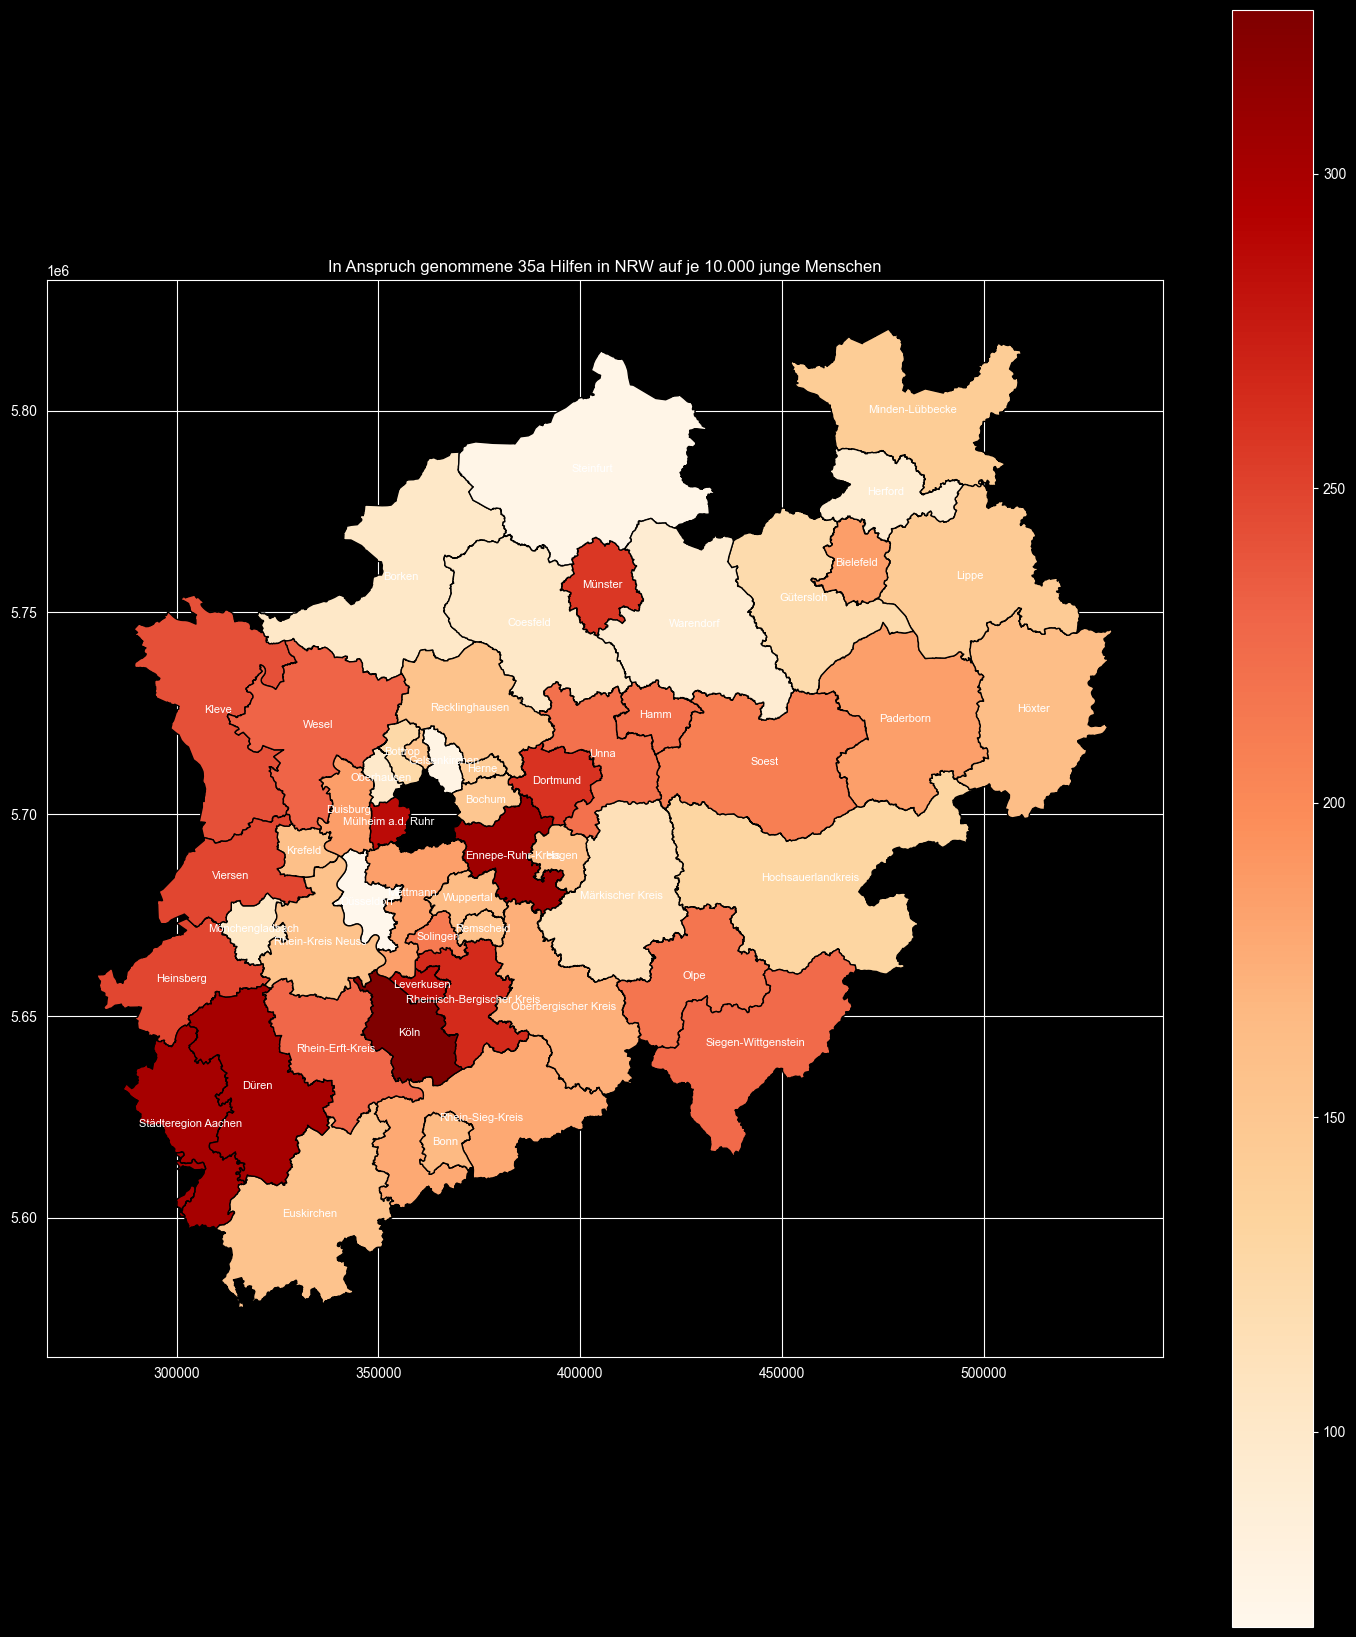

In [9]:
# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(18, 21))
nrw.plot(column="35a Hilfen pro 10000", ax=ax, legend=True, cmap="OrRd", edgecolor="black")

for idx, row in nrw.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    else:  # MultiPolygon
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['GN'], fontsize=8, ha='center', va='center')

ax.set_title("In Anspruch genommene 35a Hilfen in NRW auf je 10.000 junge Menschen")
plt.show()

In [10]:
desc= df["35a Hilfen pro 10000"].agg(
    mean="mean",
    std="std",
    var="var",
    min="min",
    max="max"
)

print(desc)


mean     182.865385
std       67.057198
var     4496.667798
min       69.000000
max      326.000000
Name: 35a Hilfen pro 10000, dtype: float64


In [11]:
stats = df.groupby("Typ")["35a Hilfen pro 10000"].agg(["mean", "std", "min", "max"])
stats["span"]= stats["max"]- stats["min"]
stats["vc"] = stats["std"] / stats["mean"]
print(stats)


                        mean        std  min  max  span        vc
Typ                                                              
Kreis             180.366667  62.889330   74  306   232  0.348675
Kreisfreie Stadt  180.809524  70.852395   69  326   257  0.391862
Städteregion      301.000000        NaN  301  301     0       NaN
